In [27]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
from emcee import autocorr
rng = np.random.default_rng(108)

### Q1

We consider an unknown two-dimensional location
$$
x = (x_1, x_2)^\top \in \mathbb{R}^2.
$$
We use the parametric \emph{banana prior}
$$
p(x_1) = \mathcal{N}(x_1; 0, \sigma_1^2),
$$
$$
p(x_2 \mid x_1) = \mathcal{N}\!\left(x_2;\, b(x_1^2 - \kappa),\, \sigma_2^2\right),
$$
and the one-point range likelihood
$$
p(y \mid x) = \mathcal{N}\!\left(y;\, \lVert x - s \rVert_2,\, \sigma_y^2\right).
$$
(where $x = (x_1, x_2) $)

For this coursework, we use
$$
\sigma_1 = 2,\quad
b = 0.25,\quad
\kappa = 4,\quad
\sigma_2 = 0.3,\quad
s = (0,0)^\top,\quad
y = 4.5,\quad
\sigma_y = 0.2.
$$

This is a Bayesian estimation problem, where we are trying to derive the posterior distribution $p(x \mid y)$ which represents our uncertainty of the 2D location given a noisy range measurement y given by the sensor (we assume it is centered at the origin).

Let's derive the target posterior explicitly using Bayes rule (and plugging all the parameters w already set to predefined constants):

$$
\bar{p}_\star(x \mid y) = p(x)p(y \mid x) = p(x_1)p(x_2 \mid x_1) =
$$
$$ 
\mathcal{N}(x_1; 0, \sigma_1^2)\mathcal{N}\!\left(x_2;\, b(x_1^2 - \kappa),\sigma_2^2\right)\mathcal{N}\!\left(y;\, \lVert x - s \rVert_2^2,\, \sigma_y^2\right) = 
$$

$$
\mathcal N(x_1; 0, 4)\;
\mathcal N\!\left(x_2;\, 0.25(x_1^2 - 4),\, 0.09\right)\;
\mathcal N\!\left(4.5;\, x_1^2 + x_2^2,\, 0.04\right) \propto
$$
$$
\exp\!\left(-\frac{x_1^2}{8}\right)
\exp\!\left(
-\frac{\left[x_2 - 0.25(x_1^2 - 4)\right]^2}{0.18}
\right)
\exp\!\left(
-\frac{\left[4.5 - x_1^2 + x_2^2\right]^2}{0.08}
\right).
$$

It is convinient to also have the log-density:

$$
\log(\bar(p)_\star(x \mid y)) =  -\frac{x_1^2}{8}-\frac{\left[x_2 - 0.25(x_1^2 - 4)\right]^2}{0.18}-\frac{\left[4.5 - x_1^2 + x_2^2\right]^2}{0.08}
$$

In [42]:
# banana function for testing MCMC
def log_banana(x1, x2):
    return -x1**2 / 8 - (x2 - 0.25*(x1**2-4))**2 / 0.18

def log_likelihood(x1, x2, y=4.5):
    return - (y-np.sqrt(x1**2 + x2**2))**2 / 0.08

def log_posterior(x1, x2, y=4.5):
    return log_banana(x1, x2) + log_likelihood(x1, x2, y)

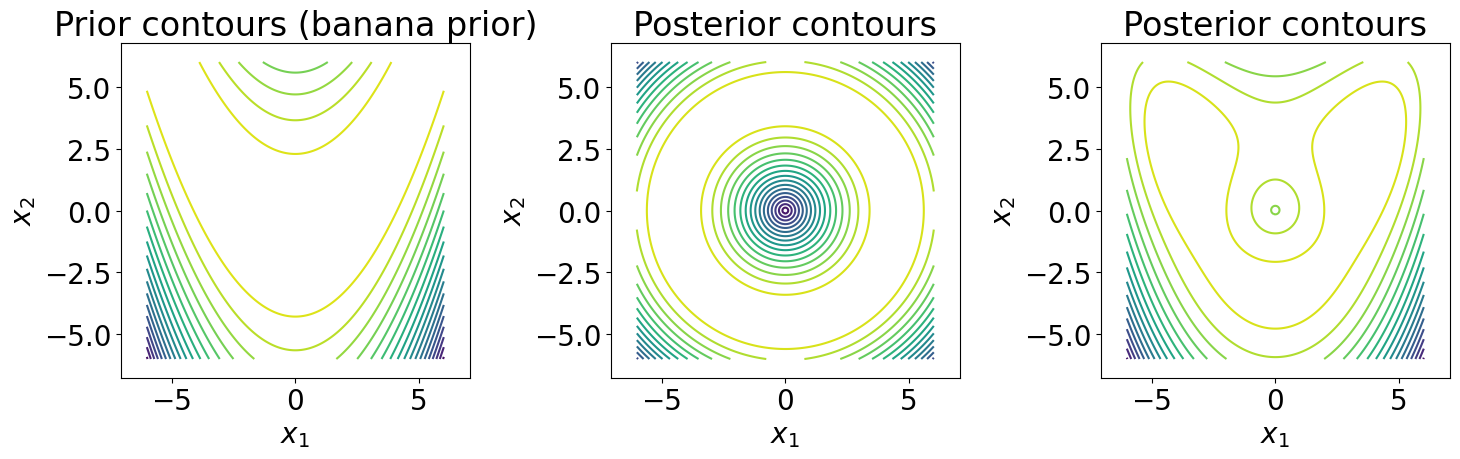

In [43]:
# grid limits
x1_min, x1_max = -6, 6
x2_min, x2_max = -6, 6

n = 300  # grid resolution
x1 = np.linspace(x1_min, x1_max, n)
x2 = np.linspace(x2_min, x2_max, n)
X1, X2 = np.meshgrid(x1, x2)

log_pior = log_banana(X1, X2)
log_lhd = log_likelihood(X1, X2)
log_post = log_posterior(X1, X2)

# Plot the countors:

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.contour(X1, X2, log_pior, levels=20)
plt.title("Prior contours (banana prior)")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.axis("equal")

plt.subplot(1, 3, 2)
plt.contour(X1, X2, log_lhd, levels=20)
plt.title("Posterior contours")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.axis("equal")

plt.subplot(1, 3, 3)
plt.contour(X1, X2, log_post, levels=20)
plt.title("Posterior contours")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.axis("equal")

plt.tight_layout()
plt.show()



### 1(b): Deriving $\nabla_x \log(p(x \mid y))$

$$
\nabla_x \log \bar p(x_1,x_2 \mid y)
=
\begin{pmatrix}
\displaystyle \frac{\partial}{\partial x_1} \log \bar p(x_1,x_2 \mid y) \\
\displaystyle \frac{\partial}{\partial x_2} \log \bar p(x_1,x_2 \mid y)
\end{pmatrix}.
$$

$$
\frac{\partial}{\partial x_1} \log \bar p(x_1,x_2 \mid y)
=
-\frac{2x_1}{8}
+
\frac{0.25 \cdot 2x_1}{0.18} \cdot
2 \left[x_2 - 0.25(x_1^2 - 4)\right]
+
2 \cdot \frac{4.5 - \sqrt{x_1^2 + x_2^2}}{0.08}
\frac{2x_1 \cdot 0.5}{\sqrt{x_1^2 + x_2^2}}.
$$

$$
\frac{\partial}{\partial x_2} \log \bar p(x_1,x_2 \mid y)
=
0 -\frac{2}{0.18}
\left[x_2 - 0.25(x_1^2 - 4)\right]
+
2 \cdot \frac{4.5 - \sqrt{x_1^2 + x_2^2}}{0.08}
\frac{2x_2 \cdot 0.5}{\sqrt{x_1^2 + x_2^2}}.
$$

Simplifying the coefficients leeds to:

$$
\nabla_x \log \bar p(x_1,x_2 \mid y)
=
\begin{pmatrix}
-\dfrac{x_1}{4}
+ \dfrac{x_1}{0.18}\left[x_2 - 0.25(x_1^2 - 4)\right]
+ \dfrac{4.5 - \sqrt{x_1^2 + x_2^2}}{0.08}
\dfrac{2x_1}{\sqrt{x_1^2 + x_2^2}}
\\
-\dfrac{1}{0.09}\left[x_2 - 0.25(x_1^2 - 4)\right]
+ \dfrac{4.5 - \sqrt{x_1^2 + x_2^2}}{0.08}
\dfrac{2x_2}{\sqrt{x_1^2 + x_2^2}}
\end{pmatrix}.
$$

### 1(c): Random Walk Metropolis-Hastings

Our aim is to extimate location, so our target density is $p(x_1, x_2 \mid y)$.

We will use normal proposal with diagonal variance, since it is symmetric, easy to sample, is supported on the whole $\mathbb{R}^2$ and only requires us to tune one parameter.

$$
q(x|x') = \mathcal{N}(x; x', \sigma_q I)
$$

We will tune $\sigma_q$ using ESS.
We will now implement the Random Walk Metropolis Hastings Algorithm to build a sampler for the target density.
Here is the pseudocode for the RWMH Algo:

copy algorithm 9 from lecture notes?

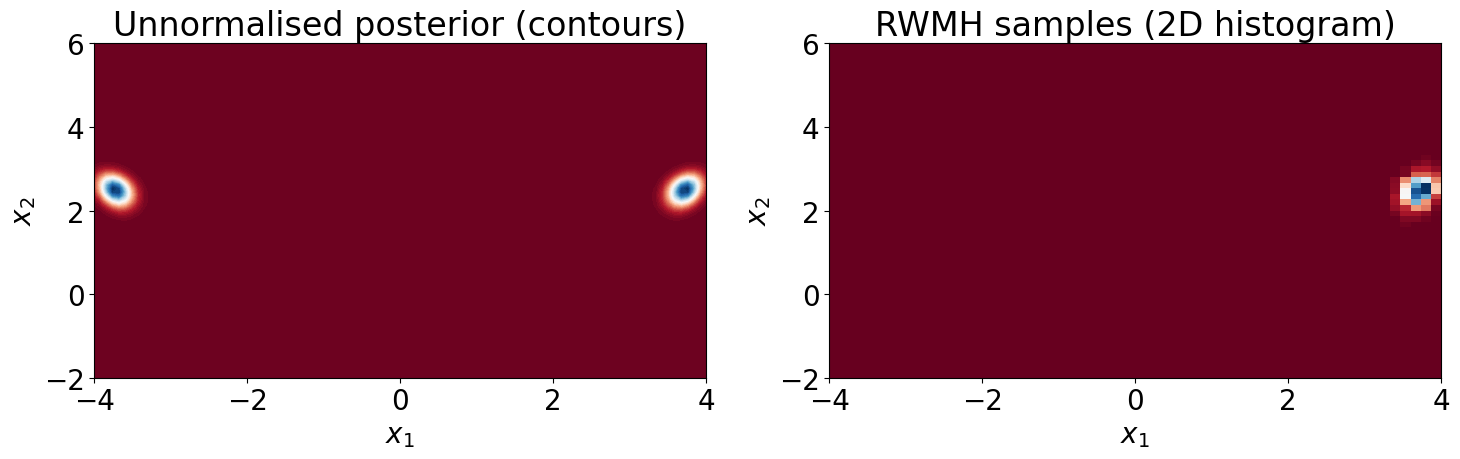

0.18061806180618062


In [44]:
def rwmh(target, N=10**6, x0=np.array([0,0]), sigma_q=0.5, burnin=200):

    samples_RW = np.zeros((N, 2))
    samples_RW[0] = x0
    
    # for acceptance ratio
    acc_count = 0

    for n in range(1, N):

        # random walk
        x_dash = samples_RW[n-1] + sigma_q * np.random.randn(2)
        # metropolis
        u = rng.uniform(0, 1)

        if np.log(u) < target(x_dash[0], x_dash[1]) - target(samples_RW[n-1, 0], samples_RW[n-1, 1]):
            samples_RW[n] = x_dash
            acc_count += 1
        else:
            samples_RW[n] = samples_RW[n-1]
    acc = acc_count / (N-1)
    return samples_RW[burnin:n], acc

mc, acc = rwmh(log_posterior, N=10000)
# for surf plot posterior 2d
x_bb = np.linspace(-4, 4, 100)
y_bb = np.linspace(-2, 6, 100)
X_bb, Y_bb = np.meshgrid(x_bb, y_bb)
Z_bb = np.exp(log_posterior(X_bb, Y_bb))

plt.figure(figsize=(15, 5))
plt.rcParams.update({'font.size': 20})

# Left: unnormalised posterior contour
plt.subplot(1, 2, 1)
plt.contourf(X_bb, Y_bb, Z_bb, levels=60, cmap='RdBu')
plt.xlim(-4, 4); plt.ylim(-2, 6)
plt.xlabel("$x_1$"); plt.ylabel("$x_2$")
plt.title("Unnormalised posterior (contours)")

# Right: 2D histogram of samples
plt.subplot(1, 2, 2)
plt.hist2d(
    mc[:, 0], mc[:, 1],
    bins=60,
    range=[[-4, 4], [-2, 6]],
    density=True,
    cmap='RdBu'
)

plt.xlabel("$x_1$"); plt.ylabel("$x_2$")
plt.title("RWMH samples (2D histogram)")

plt.tight_layout()
plt.show()

print(acc)

Text(0.5, 1.0, '')

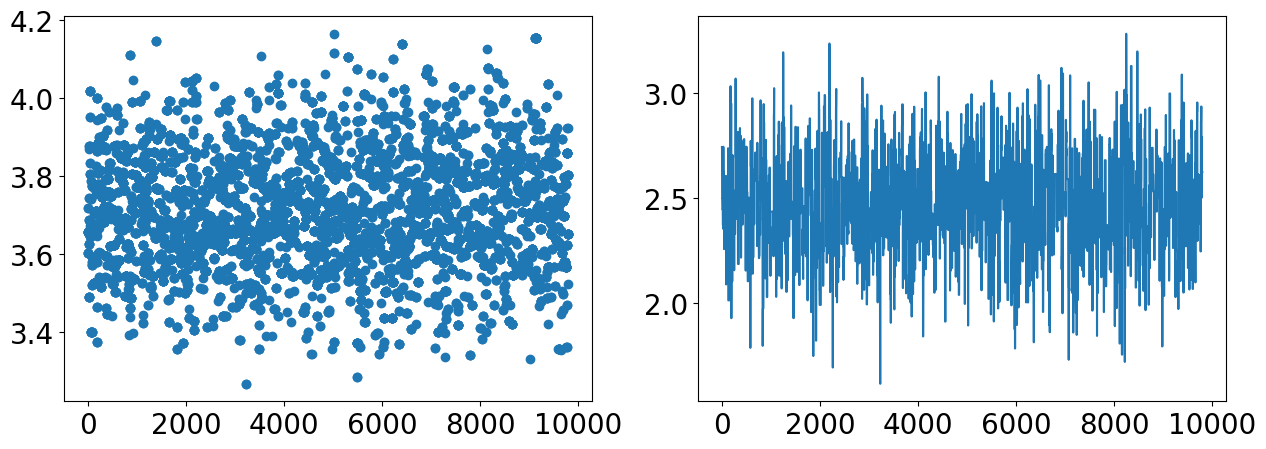

In [45]:
# Trace plots for both coordinates
trace1 = mc[:, 0]
trace2 = mc[:, 1]
x = np.arange(0, len(trace1))

plt.figure(figsize=(15,5))

plt.subplot(1, 2, 1)
plt.scatter(x, trace1)
plt.title("")

plt.subplot(1, 2, 2)
plt.plot(x, trace2)
plt.title("")

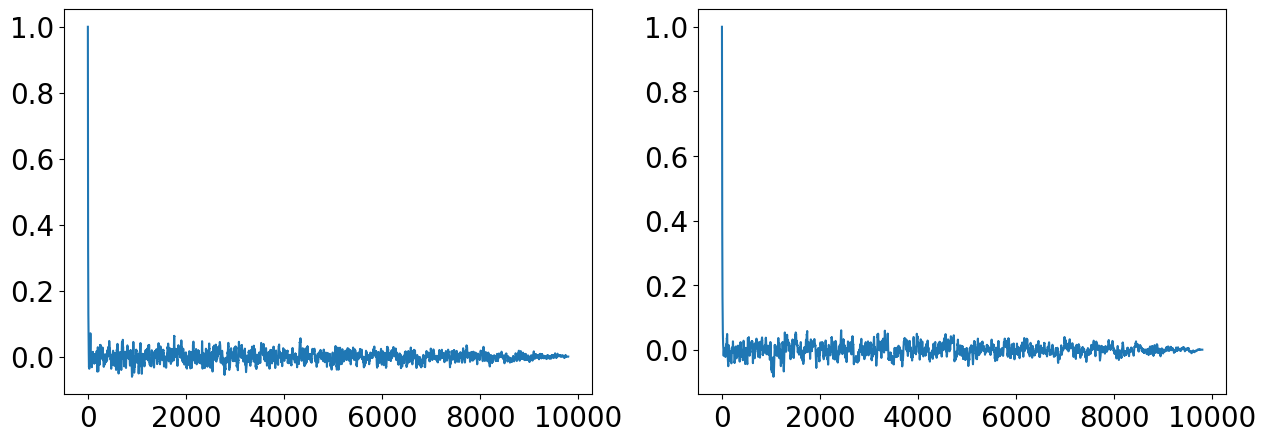

In [46]:
# Autocorrelation plots
ro_x1 = autocorr.function_1d(mc[:, 0])
x1 = np.arange(0, len(ro_x1))
ro_x2 = autocorr.function_1d(mc[:, 1])

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(x1, ro_x1)

plt.subplot(1, 2, 2)
plt.plot(x1, ro_x2)

In [47]:
def autocorrelation(x, max_lag = 1000):
    x_c = x - x.mean()
    n = len(x)

    var = np.dot(x, x) / n 
    acf = np.ones(1, 2* max_lag + 1)
    if var == 0.0:
        acf[1::] = 0.0
        return acf
    for k in range(1, 2*max_lag + 1):
        acf[k] = 1



In [48]:
sigmas = [0.1, 0.2, 0.5, 0.7, 0.8, 1.0, 2.0, 3.0]
best_ess = -np.inf

for s in sigmas:
    samples, acc = rwmh(
        log_posterior,
        N=80_000
    )

    idata = az.from_dict(
        posterior={
            "x1": samples[:, 0][None, :],
            "x2": samples[:, 1][None, :]
        }
    )

    ess = az.ess(idata, method="bulk")
    ess_min = min(float(ess["x1"]), float(ess["x2"]))


    print(f"sigma={s}, acc={acc:.3f}, minESS={ess_min:.0f}")

    if ess_min > best_ess:
        best_ess = ess_min
        best_sigma = s
print(best_sigma)

sigma=0.1, acc=0.182, minESS=5602
sigma=0.2, acc=0.180, minESS=6096
sigma=0.5, acc=0.184, minESS=6686
sigma=0.7, acc=0.185, minESS=6094
sigma=0.8, acc=0.187, minESS=61
sigma=1.0, acc=0.181, minESS=6444
sigma=2.0, acc=0.182, minESS=5987
sigma=3.0, acc=0.181, minESS=5909
0.5


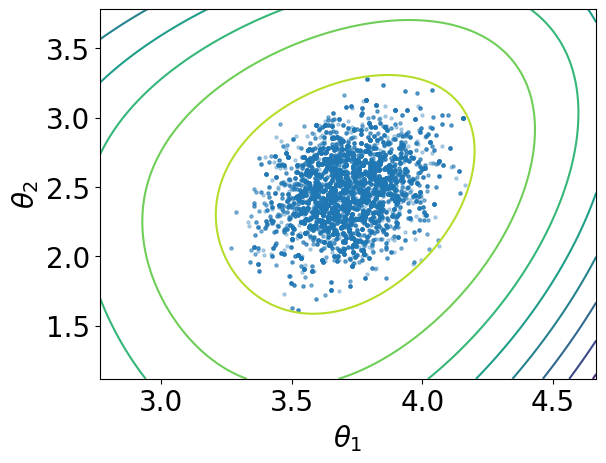

In [58]:
def samples_cloud(samples):
    # grid covering the sample range
    x = samples[:, 0]
    y = samples[:, 1]

    xs = np.linspace(x.min() - 0.5, x.max() + 0.5, 100)
    ys = np.linspace(y.min() - 0.5, y.max() + 0.5, 100)
    X, Y = np.meshgrid(xs, ys)

    # evaluate log posterior on grid
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i, j] = log_posterior(X[i, j], Y[i, j])

    # contour of log posterior (unnormalised)
    plt.contour(X, Y, Z)

    # sample cloud
    plt.scatter(x, y, s=5, alpha=0.3)

    plt.xlabel(r"$\theta_1$")
    plt.ylabel(r"$\theta_2$")
    plt.show()

samples_cloud(mc)